<a href="https://colab.research.google.com/github/yassiinn8/Machine-learning-project-/blob/main/CV_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist, fashion_mnist
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from keras.datasets import mnist
from sklearn.metrics import classification_report
from tensorflow.keras.datasets import cifar10, cifar100
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
from tensorflow.keras.layers import Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Dense, Dropout

In [ ]:
(x_train,y_train),(x_test,y_test) = fashion_mnist.load_data()

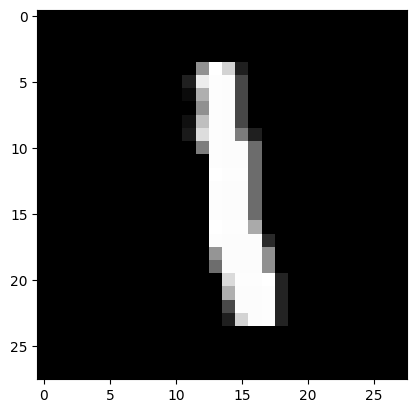

In [ ]:
plt.imshow(x_train[6],cmap='gray')

In [ ]:
x_train.shape

(60000, 28, 28)

In [ ]:
# (x_train_cifar10, y_train_cifar10), (x_test_cifar10, y_test_cifar10) = cifar10.load_data()
# (x_train_cifar100, y_train_cifar100), (x_test_cifar100, y_test_cifar100) = cifar100.load_data()

In [ ]:
# x_train , x_test = x_train / 255.0 , x_test / 255.0

In [ ]:
model = models.Sequential()
model.add(layers.Conv2D(filters = 64, kernel_size =(3,3), activation='relu', strides = 1, padding='same',input_shape=(28, 28, 1)))
model.add(layers.Conv2D(filters = 64, kernel_size =(3,3), activation='relu', strides = 1, padding='same'))
model.add(layers.MaxPooling2D((2,2) , strides = 2))
model.add(BatchNormalization())

model.add(layers.Conv2D(filters = 128, kernel_size =(3,3), activation='relu', strides = 1, padding='same'))
model.add(layers.Conv2D(filters = 128, kernel_size =(3,3), activation='relu', strides = 1, padding='same'))
model.add(layers.MaxPooling2D((2,2) , strides = 2))
model.add(BatchNormalization())

model.add(layers.Conv2D(filters = 256, kernel_size =(3,3), activation='relu',strides = 1, padding='same'))
model.add(layers.Conv2D(filters = 256,  kernel_size =(3,3), activation='relu',strides = 1, padding='same'))
model.add(layers.Conv2D(filters = 256,  kernel_size =(3,3), activation='relu',strides = 1, padding='same'))
model.add(layers.MaxPooling2D((2,2) , strides = 2))
model.add(BatchNormalization())

model.add(layers.Conv2D(filters = 512, kernel_size =(3,3), activation='relu',strides = 1, padding='same'))
model.add(layers.Conv2D(filters = 512,  kernel_size =(3,3), activation='relu',strides = 1, padding='same'))
model.add(layers.Conv2D(filters = 512,  kernel_size =(3,3), activation='relu',strides = 1, padding='same'))
model.add(layers.MaxPooling2D((2,2) , strides = 2, padding='same'))
model.add(BatchNormalization())

model.add(layers.Conv2D(filters = 512, kernel_size =(3,3), activation='relu',strides = 1,padding='same'))
model.add(layers.Conv2D(filters = 512,  kernel_size =(3,3), activation='relu',strides = 1,padding='same'))
model.add(layers.Conv2D(filters = 512,  kernel_size =(3,3), activation='relu',strides = 1,padding='same'))
model.add(layers.MaxPooling2D((2,2) , strides = 2))
model.add(BatchNormalization())

model.add(layers.Flatten())
model.add(layers.Dense(4069, activation='relu'))
model.add(layers.Dense(4069, activation='relu'))
model.add(layers.Dense(units=10, activation='softmax'))




/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])



In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 3, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 3, 3, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2, 2, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1, 1, 512)      │         2,04

 Total params: 33,408,351 (127.44 MB)

 Trainable params: 33,405,407 (127.43 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [ ]:
history = model.fit(x_train,y_train, epochs=5,batch_size=32,validation_data=(x_test, y_test))

Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/nn.py:708: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 76s 32ms/step - accuracy: 0.8562 - loss: 0.5083 - val_accuracy: 0.9536 - val_loss: 0.2926
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 70s 31ms/step - accuracy: 0.9639 - loss: 0.1772 - val_accuracy: 0.9871 - val_loss: 0.0671
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 31ms/step - accuracy: 0.9835 - loss: 0.0712 - val_accuracy: 0.9855 - val_loss: 0.0610
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 31ms/step - accuracy: 0.9865 - loss: 0.0634 - val_accuracy: 0.9691 - val_loss: 0.1250
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 31ms/step - accuracy: 0.9866 - loss: 0.0603 - val_accuracy: 0.9924 - val_loss: 0.0290


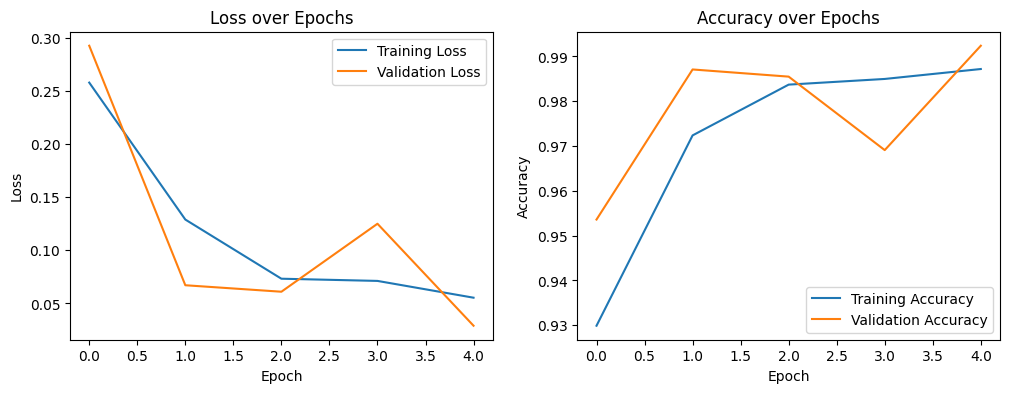

In [ ]:

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


In [ ]:
y_pred = model.predict(x_test)
y_pred_label=tf.argmax(y_pred,axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


In [ ]:
print(classification_report(y_test,y_pred_label))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       980
           1       1.00      0.99      0.99      1135
           2       0.98      1.00      0.99      1032
           3       1.00      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      1.00      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      1.00      1.00       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



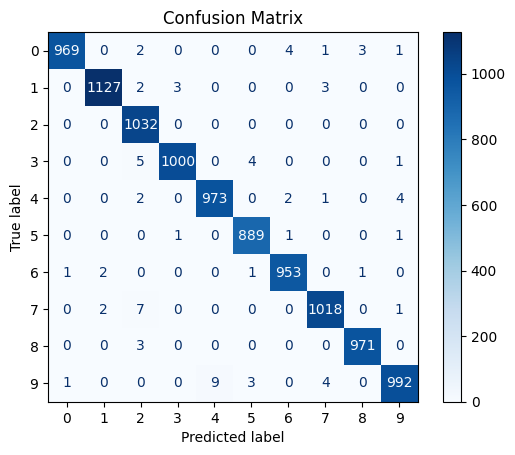

In [ ]:
cm = confusion_matrix(y_test, y_pred_label)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()